## Transformer Model from Scratch using TensorFlow


Transformers are deep learning architectures designed for sequence-to-sequence tasks like language translation and text generation. They uses a self-attention mechanism to effectively capture long-range dependencies within input sequences. In this article, we’ll implement a Transformer model from scratch using TensorFlow.

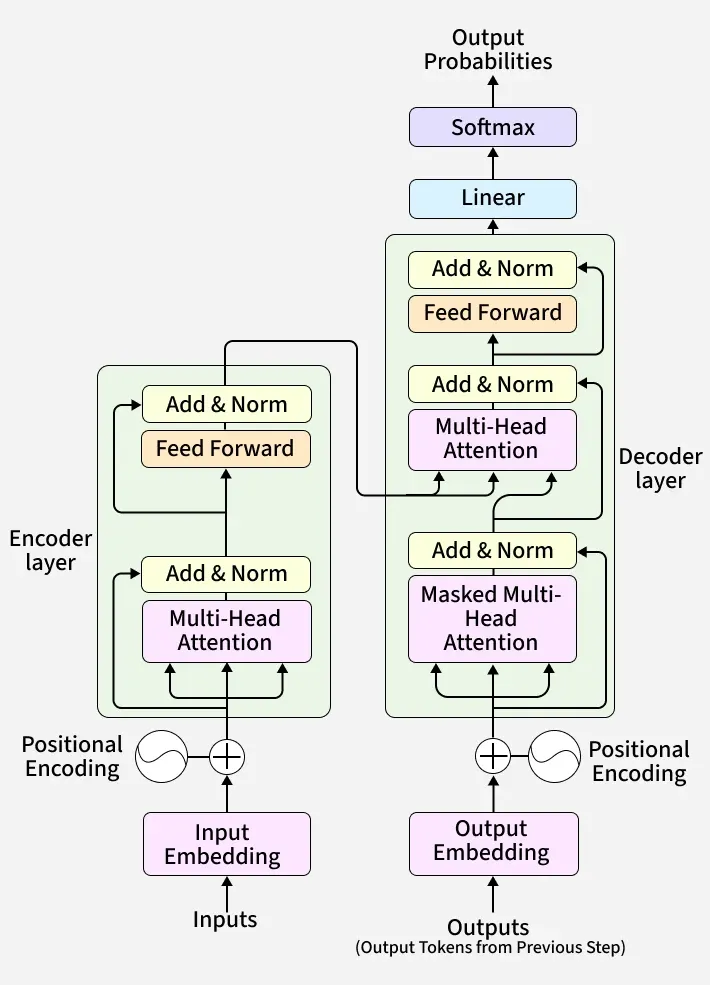

### 1. Importing Required Libraries



In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, Embedding, Dropout, LayerNormalization
from tensorflow.keras.models import Model
import numpy as np

### 2. Defining Positional Encoding

Positional encoding is added to the input embeddings to provide information about the position of tokens in the sequence. Unlike RNNs and LSTMs, Transformers do not inherently capture the sequential nature of data so positional encodings are essential for injecting this information.

* **Positional Encoding:** This function creates a unique encoding for each position in the sequence, which is added to the token embeddings.
* **Sine and Cosine:** The positions are encoded using sine and cosine functions with different frequencies to distinguish the positions.

In [2]:
def positional_encoding(position, d_model):
    angle_rads = np.arange(position)[:, np.newaxis] / np.power(10000, (2* (np.arange(d_model) // 2)) / np.float32(d_model))
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])  # apply sin to even indices
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])  # apply cos to odd indices
    return tf.cast(angle_rads[np.newaxis, ...], dtypes=tf.float32)


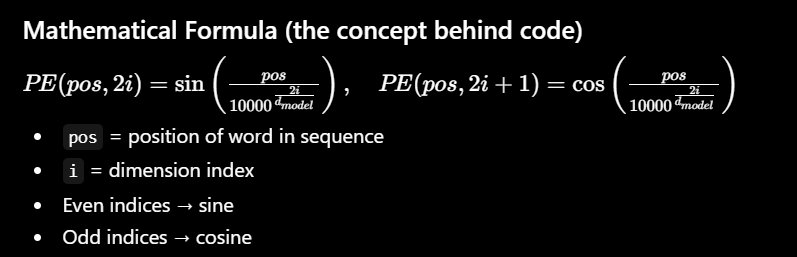

### 3. Defining Multi-Head Attention

The multi-head attention mechanism allows the model to focus on different parts of the input sequence simultaneously. It uses multiple attention heads to compute different representations of the input.

* **Multi-Head Attention:** This class performs multi-head attention by splitting the input into multiple heads which allows the model to focus on different parts of the sequence simultaneously.
* **d_model and num_heads:** d_model is the size of the embedding and num_heads refers to the number of attention heads.
* **Dense layers:** Linear transformations of the queries, keys and values are created through wq, wk and wv

In [3]:
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        assert d_model % self.num_heads == 0

        self.depth = d_model // self.num_heads

        self.wq = Dense(d_model)
        self.wk = Dense(d_model)
        self.wv = Dense(d_model)

        self.dense = Dense(d_model)

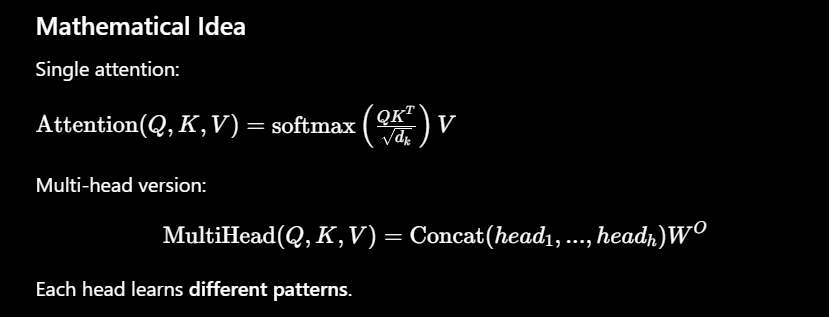

* **split_heads:** Splits the input tensor into multiple heads. The resulting tensor will have shape (batch_size, num_heads, seq_len, depth).

In [ ]:
def split_heads(self, x, batch_size):
    x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
    return tf.transpose(x, perm=[0, 2, 1, 3])

* **call:** This method performs the actual attention operation. It first computes the queries, keys and values by applying the corresponding Dense layers, splits them into heads and then calculates the attention using the scaled_dot_product_attention function.
* **scaled_dot_product_attention:** Computes attention using the scaled dot-product formula.

In [ ]:
def call(self, v, k, q, mask):
                batch_size = tf.shape(q)[0]
                q = self.wq(q)
                k = self.wk(k)
                v = self.wv(v)
                q = self.split_heads(q, batch_size)
                k = self.split_heads(k, batch_size)
                v = self.split_heads(v, batch_size)
                
                attention, attention_weights = self.scaled_dot_product_attention(q, k, v, mask)
                attention = tf.transpose(attention, perm=[0, 2, 1, 3])
                attention = tf.reshape(attention, (batch_size, -1, self.d_model))
                output = self.dense(attention)
                return output